In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
df = pd.read_excel("for_assign.xlsx")
df.head()

,device_timestamp,voltage,current
0,1719081007071,240,0.03
1,1719081007071,246,0.04
2,1719081007071,249,0.03
3,1719081007071,249,0.03
4,1719081007071,248,0.03


In [54]:
df.isnull().sum()

device_timestamp    0
voltage             0
current             0
smooth_current      4
AC_ON               0
power               0
dtype: int64

In [43]:
#time is in milliseconed so converting timestamp for better understanding
df['device_timestamp'] = pd.to_datetime(df['device_timestamp'], unit = 'ms')
df['device_timestamp']

0      2024-06-22 18:30:07.071
1      2024-06-22 18:30:07.071
2      2024-06-22 18:30:07.071
3      2024-06-22 18:30:07.071
4      2024-06-22 18:30:07.071
                 ...          
5570   2024-06-23 18:28:16.519
5571   2024-06-23 18:28:16.519
5572   2024-06-23 18:28:16.519
5573   2024-06-23 18:28:16.519
5574   2024-06-23 18:28:16.519
Name: device_timestamp, Length: 5575, dtype: datetime64[ns]

In [44]:
#normalizing part, this remove all the fluctuations and smooth the current signal
df['smooth_current'] = df['current'].rolling(window = 5).mean()
df['smooth_current'] 

0          NaN
1          NaN
2          NaN
3          NaN
4        0.032
         ...  
5570    10.760
5571    10.816
5572    11.004
5573    10.846
5574    10.606
Name: smooth_current, Length: 5575, dtype: float64

In [45]:
#Detect AC Usage, from the data Normal Current = 0.03A and AC current = 9-11A, so i choose to threshold>5A
threshold = 5
df['AC_ON']=df['current']>threshold
df['AC_ON']

0       False
1       False
2       False
3       False
4       False
        ...  
5570     True
5571     True
5572     True
5573     True
5574     True
Name: AC_ON, Length: 5575, dtype: bool

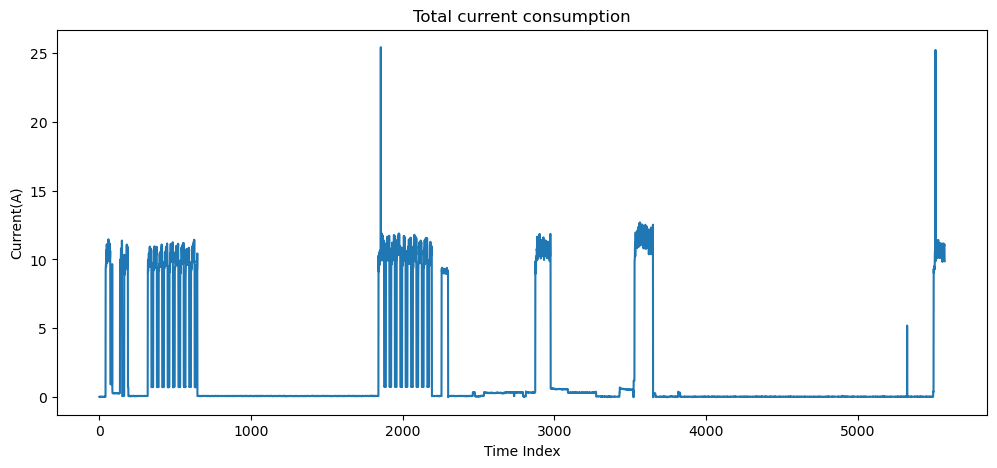

In [46]:
#GRAPH FOR TOTAL CUYRRENT CONSUMPTION
plt.figure(figsize=(12,5))
plt.plot(df['current'])
plt.title("Total current consumption")
plt.xlabel("Time Index")
plt.ylabel("Current(A)")
plt.show()
#we can clearly see huge spikes when AC starts.

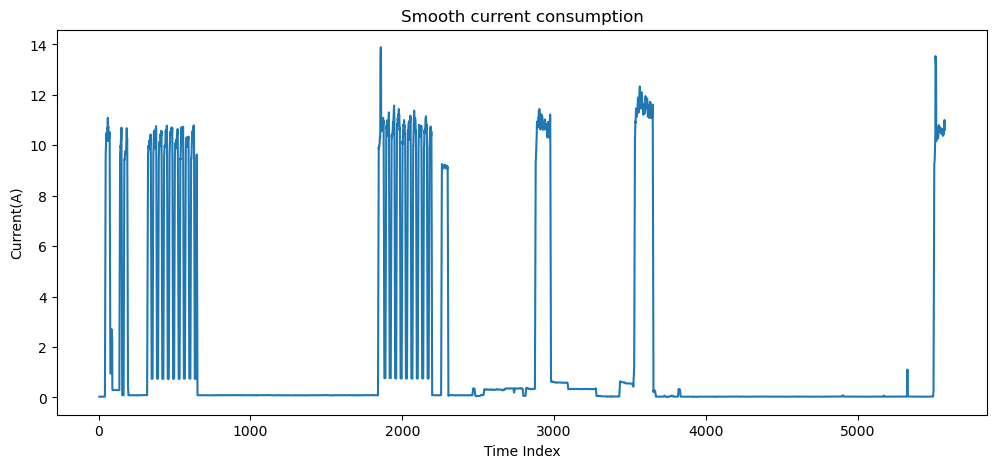

In [47]:
#GRAPH FOR SMOOTH CURRENT SIGNAL
plt.figure(figsize=(12,5))
plt.plot(df['smooth_current'])
plt.title("Smooth current consumption")
plt.xlabel("Time Index")
plt.ylabel("Current(A)")
plt.show()
#this removes noise from lights and fans

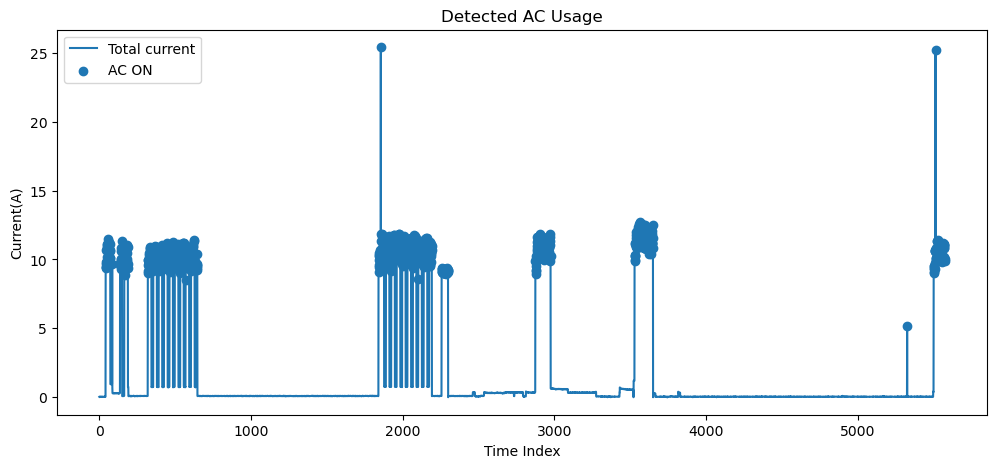

In [48]:
#AC DETECTION
#THERE IS HIGHLIGHTES POINTS WHEN AC IS RUNNING
plt.figure(figsize=(12,5))
plt.plot(df['current'],label="Total current")
plt.scatter(df.index[df['AC_ON']], df['current'][df['AC_ON']], label = "AC ON", marker = "o")
plt.title("Detected AC Usage")
plt.xlabel("Time Index")
plt.ylabel("Current(A)")
plt.legend()
plt.show()

In [49]:
#NOW , AC USAGE DURATIONS
ac_samples = df['AC_ON'].sum()
print("AC usage samples:", ac_samples)

AC usage samples: 874


In [50]:
 minutes =  ac_samples/60
 minutes

14.566666666666666

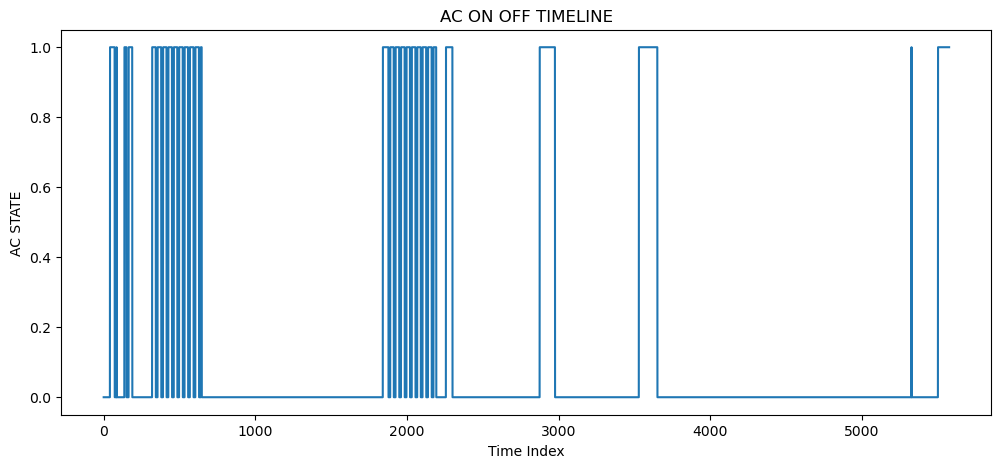

In [51]:
#THIS GRAPH SHOW AC ON/OFF TIMELINE
plt.figure(figsize=(12,5))
plt.plot(df['AC_ON'])
plt.title("AC ON OFF TIMELINE")
plt.xlabel("Time Index")
plt.ylabel("AC STATE")
plt.show()

In [52]:
#Calculate power which having formula power = voltage * current
df['power']= df['voltage']*df['current']
df['power']

0          7.20
1          9.84
2          7.47
3          7.47
4          7.44
         ...   
5570    2786.38
5571    2664.00
5572    2736.76
5573    2492.49
5574    2368.80
Name: power, Length: 5575, dtype: float64

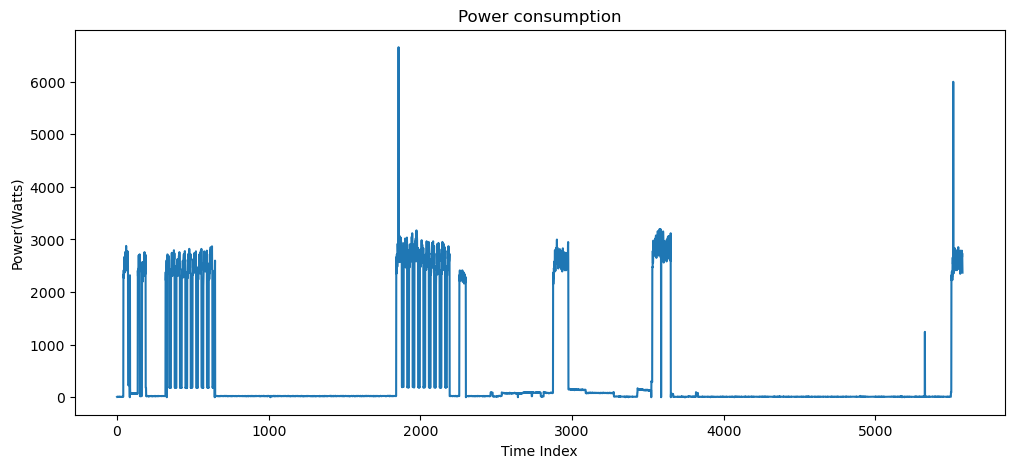

In [53]:
##GRAPH FOR POWER
plt.figure(figsize=(12,5))
plt.plot(df['power'])
plt.title("Power consumption")
plt.xlabel("Time Index")
plt.ylabel("Power(Watts)")
plt.show()